In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# assume two boreholes: x=0, x=1
mu = np.array([35.0, 35.0])
# mean rmr, static for now

sigma_sq = 8 ** 2 # variance, sigma of 8
rho = 0.8 # assume strong similarity coeff for short distance
# how calc in real? / literature
# we use kernel that auto calcs based on diff between the pairs

sigma = np.array([[sigma_sq, rho * sigma_sq], [rho*sigma_sq, sigma_sq]])

# 2x2 matrix, diagonal elements covar with onself
# couldnt just say [1,0.8] [0.8, 1]?

# TWO BOREHOLES AS A MULTIVARIATE


samples = np.random.multivariate_normal(mu, sigma, size=5) # 5 indepdent sampling pairs for joint distro of two boreholes (mu has 2 elements)

print(f"\n5 joint samples of (RMR_BH1, RMR_BH2):")
for i, s in enumerate(samples):
    # i is the box counter, s is the item counter inside the box
    print(f" Sample {i+1}: BH-1 = {s[0]:.1f}, BH-2={s[1]:.1f}")


In [ ]:
x = [0, 1, 2, 4, 5]
n = len(x)
mu_n = np.full(n, 35.0)# mu for 5 boreholes, constant priors

# kernel is simply a formula/calc for values in the covar matrix
# here we use a simple RBF kernel
#   k(x, x') = σ² * exp(-|x - x'|² / (2ℓ²))
# l is length-scale; how far aprt two points can be and still be corr

sigma_sq = 8 **2
ell = 2 #km

# compute 5x5 covar matrix

k = np.zeros((n, n)) # tuple
for i in range(n):
    for j in range(n):
        dist_sq = (x[i]-x[j]) ** 2
        k[i,j] = sigma_sq * np.exp(-dist_sq / (2*ell**2))


print("\n=== 5 BOREHOLES: COVARIANCE MATRIX FROM RBF KERNEL ===")
print(f"Locations:    x = {x} km")
print(f"Length-scale: ℓ = {ell} km")
print(f"Signal var:   σ² = {sigma_sq}")
print(f"\nCovariance matrix k:")
print(np.array2string(k, precision=2, suppress_small=True))
print(f"\nDiagonal (variances):  {np.diag(k).round(2)}")
print(f"K[0,1] (0-1km apart): {k[0,1]:.2f} — high correlation")
print(f"K[0,3] (0-4km apart): {k[0,3]:.2f} — low correlation")
print(f"K[0,4] (0-5km apart): {k[0,4]:.2f} — very low correlation")
print(f"\n→ Points close together (< ℓ) are highly correlated.")
print(f"→ Points far apart (> 2ℓ) are nearly independent.")
print(f"→ The length-scale ℓ = {ell} km controls this boundary.")

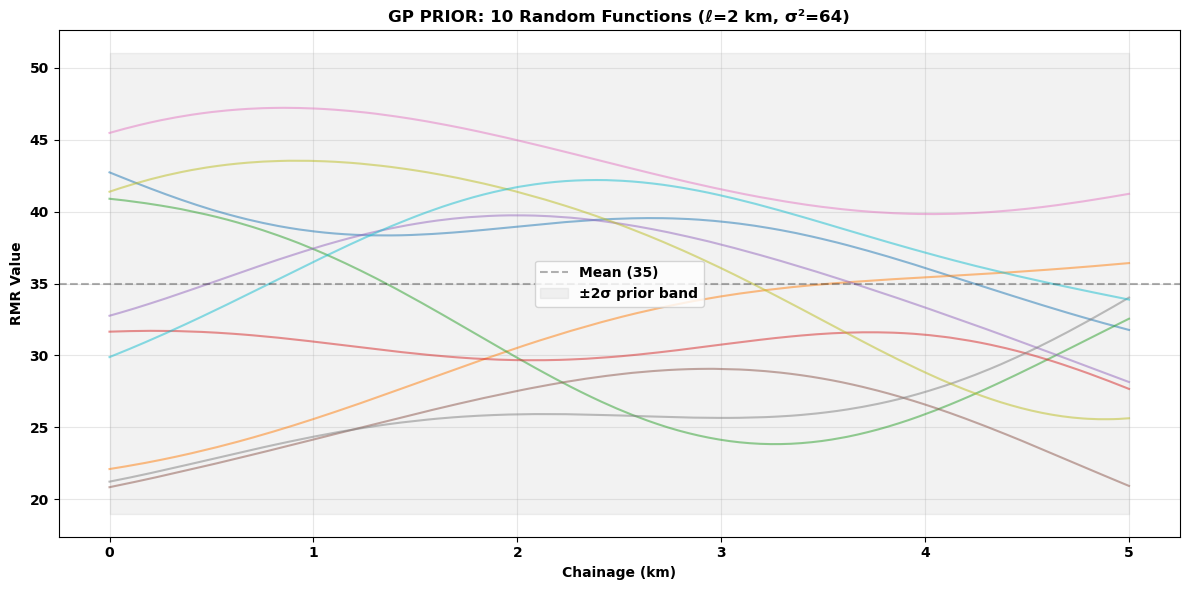

In [ ]:
# draw fxn from gp prior


x_dense =np.linspace(0, 5, 200)
n_dense = len(x_dense)
mu_dense = np.full(n_dense, 35.0) # before seeing data we assign all BH a mean of 35

# rbf kernel -> 200x200 matrix but same line of code

k_dense = np.zeros((n_dense, n_dense))
for i in range(n_dense):
    for j in range(n_dense):
        dist_sq = (x_dense[i] - x_dense[j])**2
        k_dense[i,j] = sigma_sq * np.exp(-dist_sq / (2 * ell**2))

# Add a tiny nugget for numerical stability (Cholesky needs positive definite; not zero, not negative inside root)
k_dense += 1e-6 * np.eye(n_dense)

# np.eye crete 2d identity matrix

prior_samples = np.random.multivariate_normal(mu_dense, k_dense, size = 10)

# we picking like 200 heights 10 times for 200 x values (mu)


plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(x_dense, prior_samples[i], alpha=0.5, linewidth=1.5)

plt.axhline(y=35, color='black', linestyle='--', alpha=0.3, label='Mean (35)')
plt.fill_between(x_dense,
                  35 - 2*np.sqrt(sigma_sq),
                  35 + 2*np.sqrt(sigma_sq),
                  alpha=0.1, color='gray', label='±2σ prior band')
plt.xlabel('Chainage (km)')
plt.ylabel('RMR Value')
plt.title(f'GP PRIOR: 10 Random Functions (ℓ={ell} km, σ²={sigma_sq})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Each colored line is a PLAUSIBLE RMR profile along the tunnel.
#Before seeing any data, the GP says: 'ANY of these could be reality.
#They all hover around the mean (35) and stay within ±2σ.
#They are SMOOTH because ℓ={ell} km — the kernel enforces smoothness.
#After conditioning on borehole data, most of these will be eliminated.